In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = (parent_dir + '/dfs/')


In [3]:
# Load all data
df_dreem = pd.read_csv(data_path+'df_dreem_git.csv')
df_empatica = pd.read_csv(data_path+'df_embrace_git.csv')
df_withings = pd.read_csv(data_path+'df_withings_git.csv')
df_diary = pd.read_csv(data_path+'df_diary_git.csv')
df_demographics = pd.read_csv(data_path+'SSP_participants.csv')

print(len(df_dreem), len(df_empatica), len(df_withings), len(df_diary), len(df_demographics))

2534 2426 3169 2630 200


Count recordings per subject per device and number of nights with overlapping recordings (multiple devices):

In [4]:

dreem_dates = df_dreem[['SPID','date']].groupby('SPID')['date'].apply(lambda x: pd.to_datetime(x).dt.date.unique()).to_dict()
emp_dates = df_empatica[['SPID','date']].groupby('SPID')['date'].apply(lambda x: pd.to_datetime(x).dt.date.unique()).to_dict()
with_dates = df_withings[['SPID','date']].groupby('SPID')['date'].apply(lambda x: pd.to_datetime(x).dt.date.unique()).to_dict()

def dates_to_tuples(date_dict):
    return [(subject, list(dates)) for subject, dates in date_dict.items()]

dreem_dates = dates_to_tuples(dreem_dates)
emp_dates = dates_to_tuples(emp_dates)
with_dates = dates_to_tuples(with_dates)

# Count and print all dates per device:
print('Dreem dates:', sum(len(dates) for subject, dates in dreem_dates))
print('Empatica dates:', sum(len(dates) for subject, dates in emp_dates))
print('Withings dates:', sum(len(dates) for subject, dates in with_dates))
print('Total dates:', sum(len(dates) for subject, dates in dreem_dates) + sum(len(dates) for subject, dates in emp_dates) + sum(len(dates) for subject, dates in with_dates))

emp_dates = {subject: set(dates) for subject, dates in emp_dates}
dreem_dates = {subject: set(dates) for subject, dates in dreem_dates}
with_dates = {subject: set(dates) for subject, dates in with_dates}

# Initialize a dictionary to hold the count of dates for each subject
subject_date_counts = {}

# Loop through each subject to find the intersection of dates
for subject in set(dreem_dates.keys()).union(with_dates.keys(), emp_dates.keys()):
    # Each set contains the dates where data was recorded for the subject per device:
    subject_dreem = dreem_dates.get(subject, set())
    subject_with = with_dates.get(subject, set())
    subject_emp = emp_dates.get(subject, set())

    # Create sets with dates where only one device was recorded:
    dreem_only_dates = subject_dreem - subject_emp - subject_with
    empatica_only_dates = subject_emp - subject_dreem - subject_with
    withings_only_dates = subject_with - subject_dreem - subject_emp

    # Count the number of dates/nights where each device, or combination of devices were recorded:
    subject_date_counts[subject] = {
        'dreem': len(dreem_only_dates),
        'empatica': len(empatica_only_dates),
        'withings': len(withings_only_dates),
        'dreem_emp': len(subject_dreem.intersection(subject_emp)-subject_dreem.intersection(subject_emp, subject_with)),    # dreem and embrace minus all
        'dreem_with': len(subject_dreem.intersection(subject_with)-subject_dreem.intersection(subject_emp, subject_with)),  # dreem and withings minus all
        'emp_with': len(subject_emp.intersection(subject_with)-subject_dreem.intersection(subject_emp, subject_with)),      # embrace and withings minus all   
        'all': len(subject_dreem.intersection(subject_emp, subject_with))
    }

# Now calculate the aggregate counts for each device and intersection
total_dreem = sum(count['dreem'] for count in subject_date_counts.values())
total_empatica = sum(count['empatica'] for count in subject_date_counts.values())
total_withings = sum(count['withings'] for count in subject_date_counts.values())

total_dreem_emp = sum(count['dreem_emp'] for count in subject_date_counts.values())
total_dreem_with = sum(count['dreem_with'] for count in subject_date_counts.values())
total_emp_with = sum(count['emp_with'] for count in subject_date_counts.values())

total_all = sum(count['all'] for count in subject_date_counts.values())

# Print the counts per device and total:
print('Dreem:', total_dreem+total_dreem_emp+total_dreem_with+total_all)
print('Empatica:', total_empatica+total_dreem_emp+total_emp_with+total_all)
print('Withings:', total_withings+total_dreem_with+total_emp_with+total_all)


Dreem dates: 2534
Empatica dates: 2426
Withings dates: 3169
Total dates: 8129
Dreem: 2534
Empatica: 2426
Withings: 3169


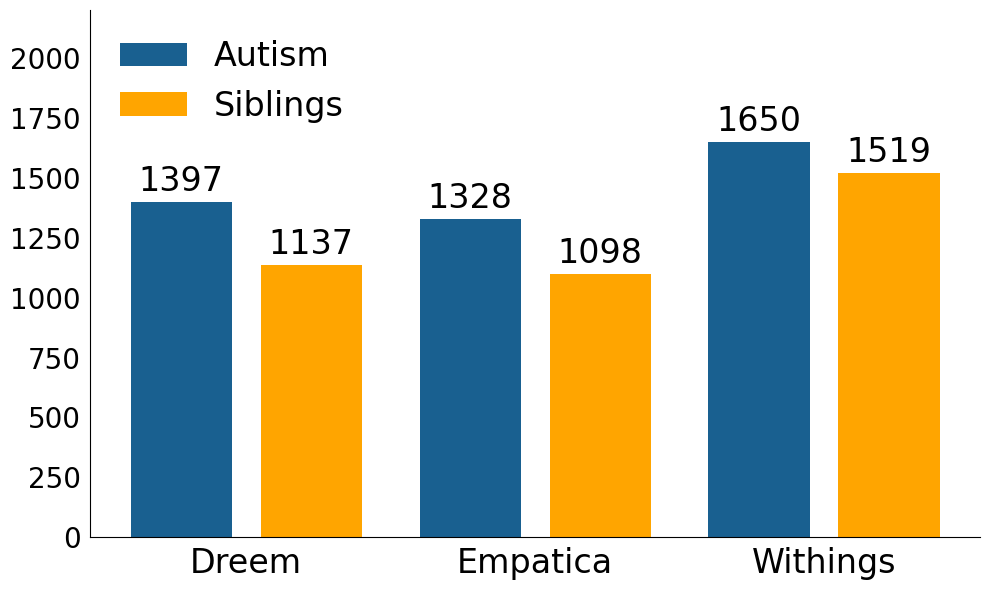

In [5]:
# Plot the nights recorded per device:

# Function to count rows and relabel user_type
def process_data(df, user_type_col='user_type'):
    # Relabel user_type values
    df[user_type_col] = df[user_type_col].replace({'ASD': 'autism', 'NASD': 'siblings'})
    
    # Count rows per user_type
    counts = df[user_type_col].value_counts().reset_index()
    counts.columns = ['user_type', 'count']  # Rename columns for clarity
    return counts

# Process each data frame
dreem_counts = process_data(df_dreem)
empatica_counts = process_data(df_empatica)
withings_counts = process_data(df_withings)

# Combine counts into lists for plotting
devices = ['Dreem', 'Empatica', 'Withings']
autism_counts = [dreem_counts.loc[dreem_counts['user_type'] == 'autism', 'count'].values[0],
                 empatica_counts.loc[empatica_counts['user_type'] == 'autism', 'count'].values[0],
                 withings_counts.loc[withings_counts['user_type'] == 'autism', 'count'].values[0]]
siblings_counts = [dreem_counts.loc[dreem_counts['user_type'] == 'siblings', 'count'].values[0],
                   empatica_counts.loc[empatica_counts['user_type'] == 'siblings', 'count'].values[0],
                   withings_counts.loc[withings_counts['user_type'] == 'siblings', 'count'].values[0]]

# Bar width and positions with gaps
bar_width = 0.35
x = np.arange(len(devices))  # Device positions
gap = 0.1  # Gap between the autism and siblings bars
autism_positions = x - bar_width / 2 - gap / 2
siblings_positions = x + bar_width / 2 + gap / 2

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars_aut = ax.bar(autism_positions, autism_counts, width=bar_width, label='Autism', color='#196090')
bars_sib = ax.bar(siblings_positions, siblings_counts, width=bar_width, label='Siblings', color='#FFA500')
aut_bar_labels = ax.bar_label(bars_aut, label_type='edge', padding=3, fontsize=24)
sib_bar_labels = ax.bar_label(bars_sib, label_type='edge', padding=3, fontsize=24)

# Add labels and title

ax.set_xticks(x)
ax.set_xticklabels(devices, fontsize=24)
ax.tick_params(axis='y', labelsize=20)
ax.legend(fontsize=24, loc='upper left', frameon=False)

# Set y axis to 0-1800
ax.set_ylim(0, 2200)

# Remove tick markers
ax.yaxis.set_ticks_position('none')
ax.xaxis.set_ticks_position('none')

# Remove top and right sides of the frame
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

Dreem: 124
Empatica: 128
Withings: 566
Dreem and Empatica: 209
Dreem and Withings: 514
Empatica and Withings: 402
3 devices: 1687
Total: 3630


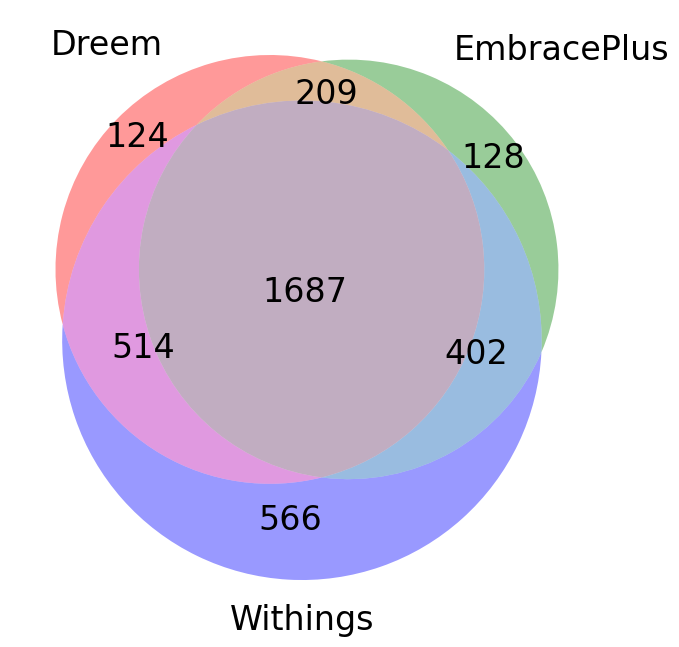

In [7]:

# Plot Venn diagram with corrected values
plt.figure(figsize=(8, 8))
venn_sizes = (total_dreem, total_empatica, total_dreem_emp, total_withings, total_dreem_with, total_emp_with, total_all)
venn = venn3(subsets=venn_sizes, set_labels=('Dreem', 'EmbracePlus', 'Withings'))

# Increase the font size of the numbers inside the Venn diagram
for text in venn.subset_labels:
    text.set_fontsize(24)

for text in venn.set_labels:
    text.set_fontsize(24)

print('Dreem:', total_dreem)
print('Empatica:', total_empatica)
print('Withings:', total_withings)
print('Dreem and Empatica:', total_dreem_emp)
print('Dreem and Withings:', total_dreem_with)
print('Empatica and Withings:', total_emp_with)
print('3 devices:', total_all)
print('Total:', sum(venn_sizes))



Demographics data 

In [ ]:
# Plot demographics:
asd_df = df_demographics[df_demographics['asd']]
sibs_df = df_demographics[~df_demographics['asd']]

sex_categories = ['Female', 'Male']
asd_df['sex'] = pd.Categorical(asd_df['sex'], categories=sex_categories)
sibs_df['sex'] = pd.Categorical(sibs_df['sex'], categories=sex_categories)

# Define bins for the Age histogram (from 10 to 17)
age_bins = range(10, 19)
sex_bins = [0, 1, 2] 
sex_labels = ['Female', 'Male']

# Plotting histogram for Sex, Age
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# Histogram for ASD and SIBS Sex side by side
ax1.hist([asd_df['sex'].cat.codes, sibs_df['sex'].cat.codes], bins=sex_bins, color=['C0', 'C1'], label=['Autism', 'Siblings'], align='left', alpha=0.6)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(sex_labels, fontsize=16)
ax1.set_xlabel('Sex', fontsize=24)
ax1.set_ylabel('Number of participants', fontsize=20)
ax1.legend(loc='upper left', fontsize=20, frameon=False) 
ax1.tick_params(axis='both', which='major', labelsize=20)

# Histogram for ASD and SIBS Age side by side
ax2.hist([asd_df['age_years'], sibs_df['age_years']], bins=age_bins, color=['C0', 'C1'], alpha=0.6)
ax2.set_xlabel('Age', fontsize=24)
ax2.set_ylabel('Number of participants', fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)


# Adjust spines for all subplots
for ax in [ax1, ax2]:
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Make left and bottom spines thicker
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()
